### Load Packages

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import re

from plots import *


fpath_meta = Path('stable_demographics.csv')
fpath_feat = Path('stable_features.csv')
fpath_feat_info = Path('feature_info.csv')
fpath_incomp = Path('incomplete_trials.csv')

### Load and merge data frames

In [2]:
df_meta = pd.read_csv(fpath_meta)
df_meta


,record_id,age,sex,height,weight,sensory_vestibular,sport,sport_current,sport_2,sport_2_current,sport_3,sport_3_current,fall_history,falls_frequency,cdc_stay_indep,abc_confidence_score,status_elite,status_vestibular
0,1,24,1,1.65,72.57,0,21.0,0.0,NaN,NaN,NaN,NaN,0,NaN,0,99.3750,0,0
1,2,30,1,1.63,62.60,0,99.0,0.0,NaN,NaN,NaN,NaN,0,NaN,0,93.7500,0,0
2,4,23,1,1.73,61.23,0,5.0,0.0,7.0,1.0,18.0,0.0,0,NaN,0,100.0000,0,0
3,9,26,1,1.55,50.80,0,7.0,0.0,NaN,NaN,NaN,NaN,0,NaN,0,98.7500,0,0
4,12,29,1,1.63,63.96,0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,100.0000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,299,86,2,1.75,63.96,0,16.0,1.0,99.0,0.0,99.0,0.0,0,NaN,0,98.1250,0,0
176,300,60,1,1.68,69.85,1,23.0,0.0,NaN,NaN,NaN,NaN,1,1.0,4,86.8750,0,1
177,335,20,1,1.57,63.50,0,13.0,1.0,NaN,NaN,NaN,NaN,0,NaN,0,100.0000,1,0
178,337,19,1,1.60,49.90,0,13.0,0.0,NaN,NaN,NaN,NaN,0,NaN,0,100.0000,1,0


In [3]:
df_feat = pd.read_csv(fpath_feat)
df_feat


,record_id,5tsts_speed,5tsts_time,frt_fwd_dist,frt_l_dist,frt_r_dist,gait_bwd_mean_speed,gait_ec_ml_dev,gait_ec_ml_dev_abs,gait_fast_speed_change,...,tandem_mean_com_speed_l,tandem_mean_com_speed_r,tandem_time_l,tandem_time_r,y_balance_back_reach_l,y_balance_back_reach_r,y_balance_cross_reach_l,y_balance_cross_reach_r,y_balance_front_reach_l,y_balance_front_reach_r
0,1,0.153278,10.016667,0.464106,0.499657,0.491448,0.751377,0.240263,0.240263,0.959254,...,0.029466,0.016109,10.000000,9.983333,1.078482,1.034203,0.942944,0.952806,0.688446,0.638827
1,2,0.219560,6.150000,0.455047,0.478707,0.490473,0.880201,0.154467,0.154467,0.696026,...,0.018430,0.019609,10.000000,10.000000,0.991189,1.013272,0.936651,0.944353,0.692233,0.586032
2,4,0.275813,5.416667,0.504816,0.529205,0.515543,0.709059,-0.096964,0.096964,1.176274,...,0.018931,0.025499,10.000000,10.000000,0.997783,1.012079,1.069393,1.021439,0.652410,0.665769
3,9,0.182754,6.916667,0.477845,0.508812,0.494111,0.893164,0.124316,0.124316,0.800029,...,0.014169,0.019458,10.000000,9.833333,1.050953,1.101992,1.027507,0.938466,0.607342,0.609311
4,12,0.120581,9.416667,0.508140,0.463211,0.516706,1.014151,-0.150849,0.150849,1.152343,...,0.013027,0.012499,8.966667,8.733333,0.978555,1.026222,1.081001,1.018428,0.716993,0.695105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,299,0.203262,8.300000,0.362860,0.436514,0.411831,0.385819,-0.054766,0.054766,0.513337,...,0.075432,0.067623,2.416667,1.400000,NaN,NaN,NaN,NaN,NaN,NaN
176,300,0.150466,9.450000,0.448909,0.437484,0.435528,0.683666,0.056145,0.056145,0.449314,...,0.036271,0.048146,10.000000,2.100000,0.970173,0.934645,0.766321,0.856336,0.665378,0.612159
177,335,0.166394,7.583333,0.407873,0.456160,0.437667,0.880186,-0.056819,0.056819,0.412699,...,0.022726,0.020189,10.000000,10.000000,0.954947,0.899332,0.896233,0.938708,0.627207,0.650211
178,337,0.182618,7.900000,0.438975,0.431972,0.433785,0.671107,0.095820,0.095820,0.614400,...,0.037564,0.027790,10.000000,9.800000,0.913527,0.887621,0.899371,0.910649,0.650046,0.658384


In [4]:
df_feat_info = pd.read_csv(fpath_feat_info)
df_feat_info


,task,feat,description,units,sign,use_for_stable
0,standing_ec,time_eo,"Hold time, eyes open",s,1,True
1,standing_ec,time_ec,"Hold time, eyes closed",s,1,True
2,standing_ec,mean_com_speed_eo,"Sway, center of mass speed, eyes open",m/s,-1,True
3,standing_ec,mean_com_speed_ec,"Sway, center of mass speed, eyes closed",m/s,-1,True
4,standing_ec,c7_std_eo,"Sway, C7 marker, eyes open",m/m,-1,True
...,...,...,...,...,...,...
75,gait_ec,ml_dev_abs,Net mediolateral deviation,m,-1,True
76,standing_ec,time,"Hold time, continuous across eyes open/closed",s,1,False
77,rtt,c7_std,"Sway, C7 marker",m/m,-1,False
78,5tsts,time,Time to complete 5 repetions,s,-1,False


In [5]:
df_ss = pd.merge(df_meta, df_feat, on='record_id', how='outer')
df_ss


,record_id,age,sex,height,weight,sensory_vestibular,sport,sport_current,sport_2,sport_2_current,...,tandem_mean_com_speed_l,tandem_mean_com_speed_r,tandem_time_l,tandem_time_r,y_balance_back_reach_l,y_balance_back_reach_r,y_balance_cross_reach_l,y_balance_cross_reach_r,y_balance_front_reach_l,y_balance_front_reach_r
0,1,24,1,1.65,72.57,0,21.0,0.0,NaN,NaN,...,0.029466,0.016109,10.000000,9.983333,1.078482,1.034203,0.942944,0.952806,0.688446,0.638827
1,2,30,1,1.63,62.60,0,99.0,0.0,NaN,NaN,...,0.018430,0.019609,10.000000,10.000000,0.991189,1.013272,0.936651,0.944353,0.692233,0.586032
2,4,23,1,1.73,61.23,0,5.0,0.0,7.0,1.0,...,0.018931,0.025499,10.000000,10.000000,0.997783,1.012079,1.069393,1.021439,0.652410,0.665769
3,9,26,1,1.55,50.80,0,7.0,0.0,NaN,NaN,...,0.014169,0.019458,10.000000,9.833333,1.050953,1.101992,1.027507,0.938466,0.607342,0.609311
4,12,29,1,1.63,63.96,0,NaN,NaN,NaN,NaN,...,0.013027,0.012499,8.966667,8.733333,0.978555,1.026222,1.081001,1.018428,0.716993,0.695105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,299,86,2,1.75,63.96,0,16.0,1.0,99.0,0.0,...,0.075432,0.067623,2.416667,1.400000,NaN,NaN,NaN,NaN,NaN,NaN
176,300,60,1,1.68,69.85,1,23.0,0.0,NaN,NaN,...,0.036271,0.048146,10.000000,2.100000,0.970173,0.934645,0.766321,0.856336,0.665378,0.612159
177,335,20,1,1.57,63.50,0,13.0,1.0,NaN,NaN,...,0.022726,0.020189,10.000000,10.000000,0.954947,0.899332,0.896233,0.938708,0.627207,0.650211
178,337,19,1,1.60,49.90,0,13.0,0.0,NaN,NaN,...,0.037564,0.027790,10.000000,9.800000,0.913527,0.887621,0.899371,0.910649,0.650046,0.658384


### Load Metadata and Features

In [6]:
# REPLACE GAIT_BWD FEATURE FOR S155 WITH PREDICTED BASED ON LIN REG WITH AGE 
train = df_ss[['age', 'gait_bwd_mean_speed']].dropna()
X = sm.add_constant(train['age'])
y = train['gait_bwd_mean_speed']
lm = sm.OLS(y, X).fit()
pred_gait_bwd_155 = lm.predict([1, df_ss.loc[df_ss['record_id']==155, 'age'].iloc[0]])[0]
df_ss.loc[df_ss['record_id']==155, 'gait_bwd_mean_speed'] = pred_gait_bwd_155

In [7]:
# REPLACE GAIT_FAST FEATURE FOR S105 WITH PREDICTED BASED ON LIN REG WITH AGE 
train = df_ss[['age', 'gait_fast_speed_change']].dropna()
X = sm.add_constant(train['age'])
y = train['gait_fast_speed_change']
lm = sm.OLS(y, X).fit()
pred_gait_fast_105 = lm.predict([1, df_ss.loc[df_ss['record_id'] == 105, 'age'].iloc[0]])[0]
# (optional) write it back into the dataframe
df_ss.loc[df_ss['record_id']== 105, 'gait_fast_speed_change'] = pred_gait_fast_105

In [8]:
# REPLACE GAIT_FAST FEATURE FOR S280 WITH PREDICTED BASED ON LIN REG WITH AGE 
train = df_ss[['age', 'gait_fast_speed_change']].dropna()
X = sm.add_constant(train['age'])
y = train['gait_fast_speed_change']
lm = sm.OLS(y, X).fit()
pred_gait_fast_280 = lm.predict([1, df_ss.loc[df_ss['record_id'] == 280, 'age'].iloc[0]])[0]
# (optional) write it back into the dataframe
df_ss.loc[df_ss['record_id']== 280, 'gait_fast_speed_change'] = pred_gait_fast_280

In [9]:
# Participant 280 completed ABC on a scale of 0 to 10 instead of 0 to 100
new_abc_280 = df_ss.loc[df_ss['record_id']== 280, 'abc_confidence_score'].iloc[0]
if new_abc_280 < 10 :
    new_abc_280 = new_abc_280*10
df_ss.loc[df_ss['record_id']== 280, 'abc_confidence_score'] = new_abc_280

### Compute Performance Scores

In [10]:
# filter only features used to compute performance scores
df_perf_feat_info = df_feat_info[df_feat_info['use_for_stable']]

# compute normalized performance features
ps_feat_cols = []
for i, row in df_perf_feat_info.iterrows():
    feature = row['task'] + '_' + row['feat']
    x = df_ss[feature].values

    colname = f'ps_{feature}'
    if row['sign'] > 0:
        df_ss[colname] = (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))
    else:
        df_ss[colname] = (np.nanmax(x) - x) / (np.nanmax(x) - np.nanmin(x))

    ps_feat_cols.append(colname)


In [11]:
# compute task performance scores
ps_cols = []
for task in df_perf_feat_info['task'].unique():
    feats = df_perf_feat_info[df_perf_feat_info.task==task]['feat']
    ps_feats = [f'ps_{task}_{c}' for c in feats]
    colname = f'ps_{task}'
    df_ss[colname] = df_ss[ps_feats].mean(axis=1)
    ps_cols.append(colname)


In [12]:
# fill NAN scores with 0 for people who did not complete the task due to difficulty
incomp_trials = pd.read_csv(fpath_incomp)
for i in incomp_trials.index:
    row_filter = (df_ss.record_id == incomp_trials.iloc[i].record_id)
    column_name = df_ss.columns[df_ss.columns.str.startswith(f'ps_{incomp_trials.iloc[i].task}')]        
    df_ss.loc[row_filter, column_name] = df_ss.loc[row_filter, column_name].fillna(0)
    if (incomp_trials.iloc[i].task == 'jump_r' or incomp_trials.iloc[i].task == 'jump_l') and df_ss.loc[row_filter, 'ps_jump'].isna().all():  
        df_ss.loc[row_filter, 'ps_jump'] = df_ss.loc[row_filter, 'ps_jump'].fillna(0) 


In [13]:
# fill features & performance score to 0 for people who had a time of 0 (i.e. couldn't do the task at all)

def extract_base_and_suffix(time_col):
    match = re.match(r'^(.*)_time_(.*)$', time_col)
    if match:
        base = match.group(1)  # everything before '_time'
        suffix = match.group(2)  # everything after '_time'
        return base, suffix
    return None, None


time_cols = [c for c in df_feat.columns if 'time' in c and 'jump' not in c]
for time_col in time_cols:
    zero_mask = df_ss[time_col] == 0
    base, suffix = extract_base_and_suffix(time_col)
    
    if base is not None and suffix is not None:
        pattern = f"^ps_{re.escape(base)}_(.*)_({re.escape(suffix)})$"
        matching_columns = [col for col in ps_feat_cols if re.match(pattern, col)]
        for col in matching_columns:
            df_ss.loc[zero_mask, col] = 0
        

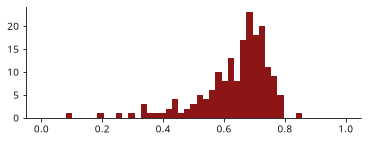

In [14]:
# compute StaBLE score

df_ss['stable_score'] = df_ss[ps_cols].mean(axis=1)

plt.figure(figsize=(6,2))
plt.hist(df_ss['stable_score'], bins=np.linspace(0, 1, 50))
plt.show()


### Subject Labels

In [15]:
#VESTIBULAR CONDITION
df_ss = pd.concat([df_ss, pd.DataFrame({'vestibular': np.full(len(df_ss), False)})], axis=1)
df_ss['vestibular'] |= (df_ss.sensory_vestibular == 1) | (df_ss.status_vestibular ==1)

# ELITE BALANCER
df_ss = pd.concat([df_ss, pd.DataFrame({'elite': np.full(len(df_ss), False)})], axis=1)
df_ss['elite'] |= (df_ss.sport_current==1) & df_ss.sport.isin((13.0, 7.0))
df_ss['elite'] |= (df_ss.sport_2_current==1) & df_ss.sport_2.isin((13.0, 7.0))
df_ss['elite'] |= (df_ss.sport_2_current==1) & df_ss.sport_2.isin((13.0, 7.0))
df_ss['elite'] |= df_ss.status_elite==1

# PREVIOUSLY SPORT
df_ss = pd.concat([df_ss, pd.DataFrame({'athlete_past': np.full(len(df_ss), False)})], axis=1)
df_ss['athlete_past'] |= (df_ss.sport_current==0) & df_ss.sport.notnull()
df_ss['athlete_past'] |= (df_ss.sport_2_current==0) & df_ss.sport_2.notnull()
df_ss['athlete_past'] |= (df_ss.sport_3_current==0) & df_ss.sport_3.notnull()

# CURRENT SPORT
df_ss = pd.concat([df_ss, pd.DataFrame({'athlete_current': np.full(len(df_ss), False)})], axis=1)
df_ss['athlete_current'] |= (df_ss.sport_current==1) & df_ss.sport.notnull()
df_ss['athlete_current'] |= (df_ss.sport_2_current==1) & df_ss.sport_2.notnull()
df_ss['athlete_current'] |= (df_ss.sport_3_current==1) & df_ss.sport_3.notnull()
df_ss['athlete_current'] |= df_ss.status_elite==1


In [16]:
# FALL RISK
df_ss = pd.concat([df_ss, pd.DataFrame({'cdc_fall_risk': np.full(len(df_ss), False)})], axis=1)
df_ss['cdc_fall_risk'] |= ((df_ss['cdc_stay_indep']>=4))

# FALL HISTORY (>=2 FALLS, NON_ATHLETE)
df_ss = pd.concat([df_ss, pd.DataFrame({'faller': np.full(len(df_ss), False)})], axis=1)
df_ss['faller'] |= (df_ss['falls_frequency'] >=2) & ~df_ss['elite'] & ~df_ss['athlete_current']


In [17]:
# MINI-BALANCE EVALUATION SYSTEMS TEST (MINI-BESTEST) RISE-TO-TOES SCORE
angle = df_ss.rtt_peak_pf
sway = df_ss.rtt_c7_std

ankle_thresh = np.mean(angle) - np.std(angle)
sway_thresh = np.mean(sway) + np.std(sway)

df_ss = pd.concat([df_ss, pd.DataFrame({'miniBEST': np.full(len(df_ss), 2)})], axis=1)
df_ss.loc[(df_ss.rtt_peak_pf < ankle_thresh), 'miniBEST'] = 1
df_ss.loc[(df_ss.rtt_c7_std > sway_thresh) , 'miniBEST'] = 1
df_ss.loc[(df_ss.rtt_time < 3), 'miniBEST'] = 0

for i in incomp_trials.index:
    row_filter = (df_ss.record_id == str(incomp_trials.iloc[i].record_id))
    if incomp_trials.iloc[i].task == 'rtt' :       
        df_ss.loc[row_filter, 'miniBEST'] = 0 



In [18]:
# 4-STAGE BALANCE TEST SCORE
df_ss = pd.concat([df_ss, pd.DataFrame({'four_stage_bt': np.full(len(df_ss), 4)})], axis=1)
df_ss.loc[((df_ss.sls_ec_time_r_eo < 9.5) | df_ss.sls_ec_time_r_eo.isna()), 'four_stage_bt'] = 3
df_ss.loc[((df_ss.tandem_time_r < 8.5)| df_ss.tandem_time_r.isna()), 'four_stage_bt'] = 2
df_ss.loc[((df_ss.semi_tandem_time_r < 8.5)| df_ss.semi_tandem_time_r.isna()), 'four_stage_bt'] = 1
df_ss.loc[((df_ss.standing_ec_time < 10) | df_ss.standing_ec_time.isna()), 'four_stage_bt'] = 0

In [19]:
# SHORT PHYSICAL PERFORMANCE BATTERY (SPPB) SCORE
df_ss = pd.concat([df_ss, pd.DataFrame({'sppb_balance': np.full(len(df_ss), 4)})], axis=1)
df_ss.loc[(df_ss.tandem_time_r < 8.5) | df_ss.tandem_time_r.isna(), 'sppb_balance'] = 3
df_ss.loc[(df_ss.tandem_time_r < 3) | df_ss.tandem_time_r.isna(), 'sppb_balance'] = 2
df_ss.loc[(df_ss.semi_tandem_time_r < 8.5) | df_ss.semi_tandem_time_r.isna(), 'sppb_balance'] = 1
df_ss.loc[(df_ss.standing_ec_time < 10 ), 'sppb_balance'] = 0

df_ss = pd.concat([df_ss, pd.DataFrame({'sppb_gait': np.full(len(df_ss), 0)})], axis=1)
df_ss.loc[(df_ss.gait_time_3m > 6.52), 'sppb_gait'] = 1
df_ss.loc[(df_ss.gait_time_3m > 4.66) & (df_ss.gait_time_3m <= 6.52), 'sppb_gait'] = 2
df_ss.loc[(df_ss.gait_time_3m > 3.62) & (df_ss.gait_time_3m <= 4.66), 'sppb_gait'] = 3
df_ss.loc[(df_ss.gait_time_3m <= 3.62), 'sppb_gait'] = 4

df_ss = pd.concat([df_ss, pd.DataFrame({'sppb_5tsts': np.full(len(df_ss), 0)})], axis=1)
df_ss.loc[(df_ss['5tsts_time'] > 60), 'sppb_5tsts'] = 0
df_ss.loc[(df_ss['5tsts_time'] >= 16.7) & (df_ss['5tsts_time'] < 60), 'sppb_5tsts'] = 1
df_ss.loc[(df_ss['5tsts_time'] >= 13.7) & (df_ss['5tsts_time'] < 16.7), 'sppb_5tsts'] = 2
df_ss.loc[(df_ss['5tsts_time'] >= 11.2) & (df_ss['5tsts_time'] < 13.7), 'sppb_5tsts'] = 3
df_ss.loc[(df_ss['5tsts_time'] < 11.2), 'sppb_5tsts'] = 4

df_ss['sppb'] = df_ss['sppb_balance'] + df_ss['sppb_5tsts'] + df_ss['sppb_gait']


In [20]:
# Export Performance Scores to CSV
df_ss.to_csv('stable_scores.csv', index=False)

### SUMMARY STATISTICS

In [21]:
# Participants
print(f'Number of participants: {df_ss.record_id.nunique()}')
print(f'Number of female participants: {sum(df_ss.sex==1)}')
print(f'Number of male participants: {sum(df_ss.sex==2)}')
print(f'Age range: {np.min(df_ss.age)} - {np.max(df_ss.age)}')

Number of participants: 180
Number of female participants: 117
Number of male participants: 63
Age range: 18 - 87


In [22]:
# StaBLE Score and Task Score Stats
statistics = []
statistics.append({
        'Score': 'StaBLE Score',
        'Mean': np.mean(df_ss.stable_score),
        'Standard Dev': np.std(df_ss.stable_score),
        'Min': np.min(df_ss.stable_score),
        'Max': np.max(df_ss.stable_score)
    })
for col in ps_cols:
    mean = np.mean(df_ss[col])
    std_dev = np.std(df_ss[col])
    min_val = np.min(df_ss[col])
    max_val = np.max(df_ss[col])
    
    statistics.append({
        'Score': col,
        'Mean': mean,
        'Standard Dev': std_dev,
        'Min': min_val,
        'Max': max_val
    })
# Create a DataFrame from the statistics
task_dist_df = pd.DataFrame(statistics)

# Display the statistics DataFrame
print(task_dist_df.round(4))

             Score    Mean  Standard Dev     Min     Max
0     StaBLE Score  0.6371        0.1195  0.0848  0.8444
1   ps_standing_ec  0.9025        0.0754  0.4173  0.9836
2           ps_rtt  0.5667        0.1921  0.0000  0.9470
3   ps_semi_tandem  0.8507        0.0980  0.3939  0.9772
4        ps_tandem  0.7996        0.1679  0.0000  0.9797
5        ps_sls_ec  0.8147        0.1912  0.0000  0.9693
6       ps_sls_rtt  0.5680        0.2130  0.0000  0.9554
7    ps_sls_rtt_ec  0.5827        0.2146  0.0000  0.8874
8           ps_frt  0.6006        0.1428  0.0000  0.9333
9         ps_5tsts  0.4136        0.2026  0.0000  1.0000
10    ps_y_balance  0.4829        0.1739  0.0000  0.7874
11         ps_jump  0.6159        0.2590  0.0000  1.0000
12        ps_march  0.7929        0.1466  0.0000  0.9751
13         ps_gait  0.5460        0.1805  0.0000  1.0000
14    ps_gait_fast  0.3818        0.1887  0.0000  1.0000
15   ps_gait_pivot  0.6632        0.1411  0.0000  0.9831
16  ps_gait_tandem  0.5690     

In [23]:
print(f'{sum(df_ss.fall_history==1)} participants reported a fall in the previous year with a mean age of {np.mean(df_ss[df_ss.fall_history==1].age).round(1)}')
print(f'{len(df_ss[(df_ss.fall_history==1) & (df_ss.athlete_current==True)])} participants who reported a fall are competitive athletes with {len(df_ss[(df_ss.falls_frequency==4) & (df_ss.athlete_current==True)])} reporting 4 or more falls')

38 participants reported a fall in the previous year with a mean age of 49.4
8 participants who reported a fall are competitive athletes with 4 reporting 4 or more falls
